# 03 - Multi-class Classifier: Which category?

**Problem**: 5 ana kategoriden hangisi? (`appliances` / `furniture` / `apparel` / `stationery` / `accessories`)

**Veri**: `sessions_cat.parquet` — `category_code` recovery ile doldurulmuş 131,297 session.

**Strateji**: LogReg baseline + XGBoost `multi:softprob` primary. Primary metrik **Macro F1** (az temsil edilen sınıflara eşit ağırlık).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.feature_engineering import FEATURE_COLS

DATA = Path("..") / "data" / "processed"
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

from sklearn.preprocessing import LabelEncoder
from src.model_multiclass import split, train_baseline, train_primary, evaluate

## 1. Veriyi yükle

In [2]:
sessions_cat = pd.read_parquet(DATA / "sessions_cat.parquet")
X = sessions_cat[FEATURE_COLS].astype("float32")
y = sessions_cat["main_cat"].astype("string")
print(f"X: {X.shape}  y: {y.shape}")
print(y.value_counts())

X: (131297, 14)  y: (131297,)
main_cat
appliances     59522
furniture      24462
apparel        19037
stationery     15977
accessories    12299
Name: count, dtype: int64[pyarrow]


## 2. Train/test split (stratified)

In [3]:
X_train, X_test, y_train, y_test = split(X, y)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
labels = list(le.classes_)
print(f"train: {len(y_train):,}  test: {len(y_test):,}")
print(f"labels (alpha): {labels}")

train: 105,037  test: 26,260
labels (alpha): ['accessories', 'apparel', 'appliances', 'furniture', 'stationery']


## 3. Baseline — Multinomial Logistic Regression

In [4]:
%time baseline = train_baseline(X_train, y_train)
base_metrics = evaluate(baseline, X_test, y_test, labels, encoded=False)
print(f"macro_f1    = {base_metrics['macro_f1']:.4f}")
print(f"weighted_f1 = {base_metrics['weighted_f1']:.4f}")
print("per-class F1:")
pd.Series(base_metrics["per_class_f1"]).round(3)

CPU times: total: 3.02 s
Wall time: 2.7 s


macro_f1    = 0.5560
weighted_f1 = 0.6173
per-class F1:


accessories    0.506
apparel        0.483
appliances     0.756
furniture      0.482
stationery     0.553
dtype: float64

## 4. Primary — XGBoost (`multi:softprob`)

In [5]:
%time primary = train_primary(X_train, y_train_enc, n_classes=len(labels))
prim_metrics = evaluate(primary, X_test, y_test_enc, labels, encoded=True)
print(f"macro_f1    = {prim_metrics['macro_f1']:.4f}")
print(f"weighted_f1 = {prim_metrics['weighted_f1']:.4f}")
print("per-class F1:")
pd.Series(prim_metrics["per_class_f1"]).round(3)

CPU times: total: 1min 40s
Wall time: 8.57 s


macro_f1    = 0.8548
weighted_f1 = 0.8780
per-class F1:


accessories    0.866
apparel        0.752
appliances     0.927
furniture      0.883
stationery     0.846
dtype: float64

## 5. Model karşılaştırması

In [6]:
comp = pd.DataFrame({
    "LogReg":  [base_metrics["macro_f1"], base_metrics["weighted_f1"]],
    "XGBoost": [prim_metrics["macro_f1"], prim_metrics["weighted_f1"]],
}, index=["Macro F1", "Weighted F1"]).round(4)
display(comp)

,LogReg,XGBoost
Macro F1,0.5560,0.8548
Weighted F1,0.6173,0.8780


## 6. Confusion matrix — sayılar ve row-normalize

Sol: ham sayılar. Sağ: her satır kendi toplamına bölünmüş — per-class recall'u doğrudan gösterir. Diyagonal baskınlığı modelin doğru sınıflandırmasını yansıtır.

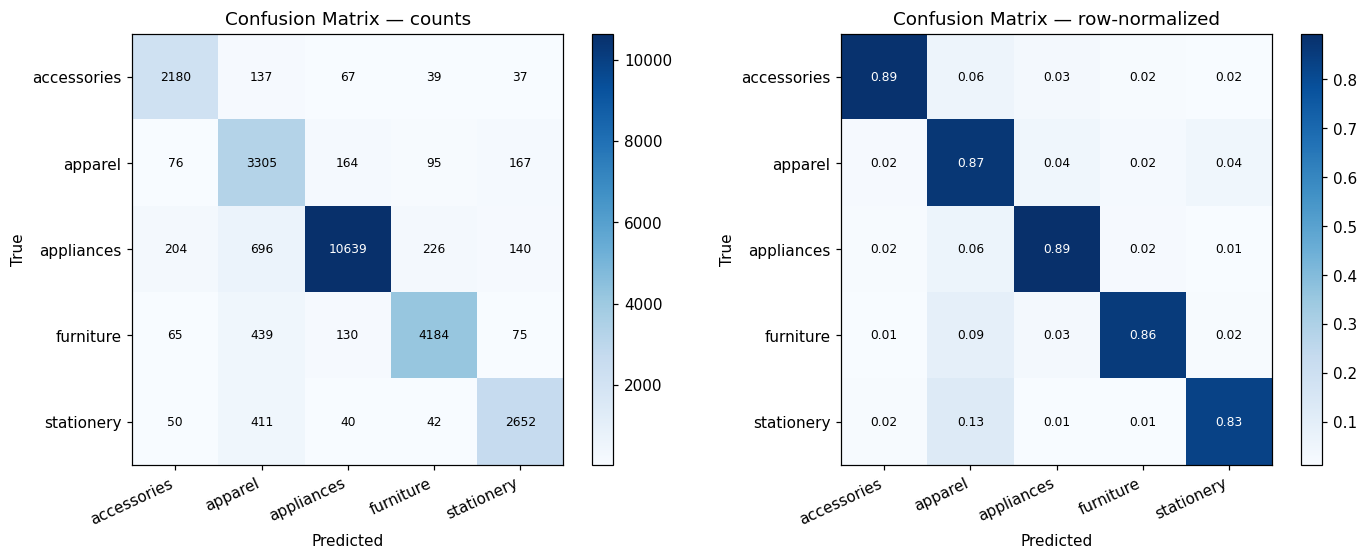

In [7]:
from sklearn.metrics import confusion_matrix
import numpy as np

pred_enc = primary.predict(X_test)
cm = confusion_matrix(y_test_enc, pred_enc, labels=list(range(len(labels))))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, fmt, title in [
    (axes[0], cm, "d", "Confusion Matrix — counts"),
    (axes[1], cm_norm, ".2f", "Confusion Matrix — row-normalized"),
]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thr = mat.max()/2
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = mat[i, j]
            ax.text(j, i, format(v, fmt), ha="center", va="center",
                    color="white" if v > thr else "black", fontsize=8)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 7. Feature importance (XGBoost)

Hangi feature'lar kategori ayırımını belirliyor? Fiyat aralıkları baskın sinyal olmayı bekliyoruz (appliances >> stationery fiyat olarak).

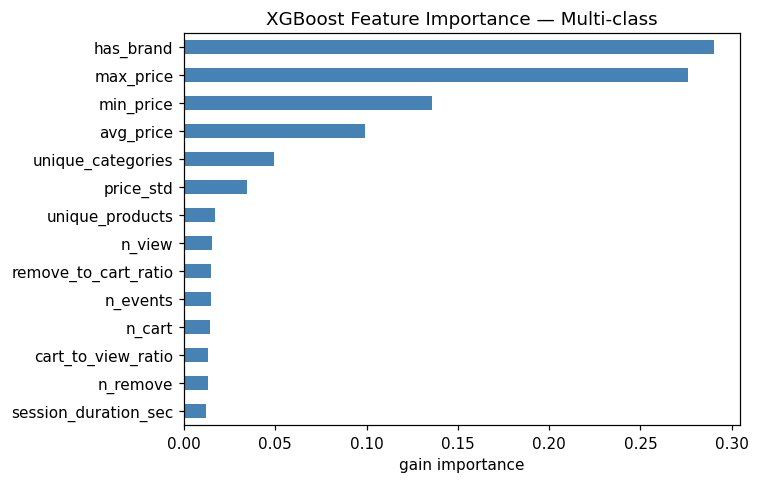

In [8]:
imp = pd.Series(primary.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("gain importance")
ax.set_title("XGBoost Feature Importance — Multi-class")
plt.tight_layout(); plt.show()

## 8. Sonuç

| Model | Macro F1 | Weighted F1 |
|---|---:|---:|
| LogReg | ~0.56 | ~0.62 |
| **XGBoost** | **~0.85** | **~0.88** |

- Baseline → primary kazancı **+0.30 Macro F1** — non-lineer etkileşimlerin katkısı açık.
- En kolay sınıf **appliances** (F1 ~0.93): fiyat + brand + duration ayırıcı.
- En zor sınıf **apparel** (F1 ~0.75): fiyat dağılımı diğer kategorilerle örtüşüyor — en büyük karışıklık `appliances ↔ apparel`.
- **Leak YOK**: feature'lar non-purchase event'lerden hesaplandı; main_cat target olarak dışlandı.
